# Capítulo 15 — Regresión lineal

En el capítulo anterior reconocimos problemas de regresión y analizamos errores individuales de predicciones ya disponibles. Ahora entrenaremos nuestro primer modelo para predecir valores numéricos.

La regresión lineal nos permitirá conectar una ecuación con un modelo real: veremos cómo una recta resume una tendencia, qué significan la pendiente y el intercepto, cómo se combinan varias variables y qué señales pueden advertirnos que una relación lineal resulta insuficiente.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- entrenar una regresión lineal simple con `LinearRegression`;
- representar los datos y la recta ajustada;
- interpretar la pendiente y el intercepto dentro del contexto;
- obtener una predicción mediante la ecuación aprendida;
- distinguir regresión lineal simple y múltiple;
- reconstruir una predicción a partir de varios coeficientes;
- interpretar coeficientes positivos y negativos con cautela;
- reconocer el efecto de las unidades de medida;
- observar patrones en los residuos;
- identificar riesgos asociados con valores extremos, relaciones curvas y extrapolaciones.

Las métricas agregadas de regresión se desarrollarán en el capítulo siguiente.


## 1. Importar las herramientas

Usaremos Pandas y NumPy para organizar los datos, Matplotlib para las visualizaciones y herramientas de `scikit-learn` para separar los casos y entrenar los modelos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


## 2. Un dataset didáctico de viviendas

Continuaremos con el contexto del capítulo anterior. Crearemos un conjunto reproducible de 48 viviendas con variables que podrían estar disponibles al momento de realizar una estimación.

Los precios son ficticios y fueron generados únicamente con fines didácticos. No representan tasaciones ni valores reales de mercado.


In [2]:
rng = np.random.default_rng(15)
n_viviendas = 48

superficie = rng.integers(45, 151, size=n_viviendas)
ambientes_estimados = np.rint(superficie / 25).astype(int)
ambientes = np.clip(
    ambientes_estimados + rng.integers(-1, 2, size=n_viviendas),
    1,
    6,
)
antiguedad = rng.integers(0, 51, size=n_viviendas)
distancia = np.round(rng.uniform(1, 15, size=n_viviendas), 1)
barrio = rng.choice(
    ["Centro", "Norte", "Oeste", "Sur"],
    size=n_viviendas,
)

efecto_barrio = pd.Series(barrio).map({
    "Centro": 18000,
    "Norte": 12000,
    "Oeste": 3000,
    "Sur": -4000,
}).to_numpy()

precio = (
    25000
    + 1050 * superficie
    + 6500 * ambientes
    - 550 * antiguedad
    - 2200 * distancia
    + efecto_barrio
    + rng.normal(0, 7000, size=n_viviendas)
)

viviendas = pd.DataFrame({
    "id_vivienda": [f"V{i:03d}" for i in range(1, n_viviendas + 1)],
    "superficie_m2": superficie,
    "ambientes": ambientes,
    "antiguedad_anios": antiguedad,
    "distancia_centro_km": distancia,
    "barrio": barrio,
    "precio_usd": np.round(precio / 500) * 500,
})

viviendas.head()


,id_vivienda,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,barrio,precio_usd
0,V001,143,6,47,3.9,Centro,210500.0
1,V002,118,6,21,6.7,Oeste,154000.0
2,V003,119,6,2,4.7,Norte,184500.0
3,V004,131,6,49,3.8,Oeste,172000.0
4,V005,70,4,47,4.7,Norte,105000.0


Cada fila representa una vivienda. `precio_usd` será la variable objetivo. `id_vivienda` identifica los casos, pero no describe una característica que deba usar el modelo.


In [3]:
pd.DataFrame({
    "filas": [viviendas.shape[0]],
    "columnas": [viviendas.shape[1]],
    "precio_minimo": [viviendas["precio_usd"].min()],
    "precio_maximo": [viviendas["precio_usd"].max()],
    "valores_faltantes": [viviendas.isna().sum().sum()],
})


,filas,columnas,precio_minimo,precio_maximo,valores_faltantes
0,48,7,35000.0,212000.0,0


## 3. Observar la relación entre superficie y precio

Comenzaremos con una regresión lineal simple. La única variable de entrada será `superficie_m2`.

Antes de entrenar, conviene observar los datos. Buscamos una tendencia aproximadamente ascendente, aunque no esperamos que todos los puntos queden alineados: viviendas con superficies parecidas pueden tener precios diferentes por variables que este primer modelo no considera.


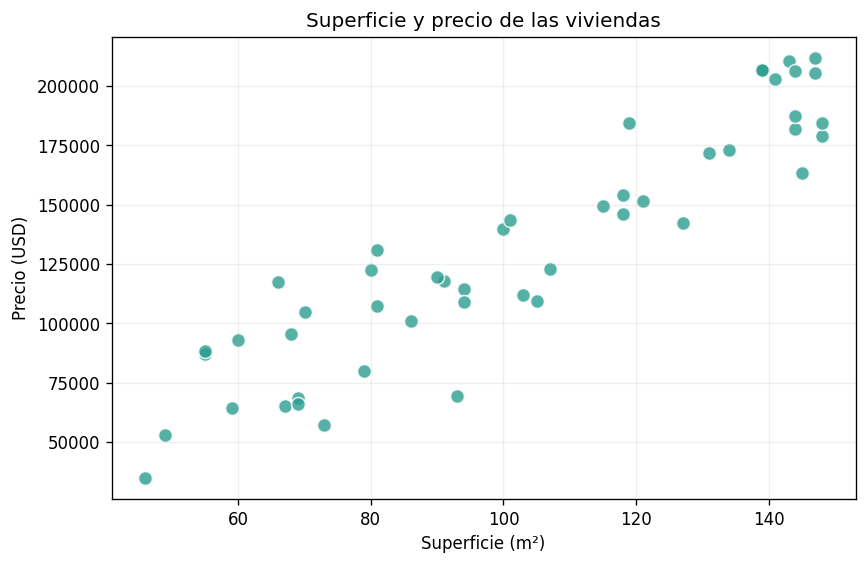

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(
    viviendas["superficie_m2"],
    viviendas["precio_usd"],
    color="#2A9D8F",
    alpha=0.8,
    edgecolor="white",
    s=70,
)
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (USD)")
plt.title("Superficie y precio de las viviendas")
plt.grid(alpha=0.2)
plt.show()


La nube de puntos muestra una tendencia general: las viviendas de mayor superficie suelen tener precios más altos. Sin embargo, la superficie no explica por sí sola todas las diferencias.

Esta situación es adecuada para estudiar qué puede capturar una recta y qué información queda fuera de ella.


## 4. Separar entrenamiento y prueba

Aunque el objetivo de este capítulo es comprender el modelo, mantendremos una práctica correcta: aprenderemos la recta únicamente con el conjunto de entrenamiento y reservaremos algunos casos para observar predicciones sobre datos no usados durante el ajuste.


In [5]:
X_simple = viviendas[["superficie_m2"]]
y = viviendas["precio_usd"]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.25,
    random_state=15,
)

pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(X_train_s), len(X_test_s)],
})


,conjunto,filas
0,Entrenamiento,36
1,Prueba,12


La correspondencia entre entradas y resultados se conserva: `X_train_s` se relaciona con `y_train`, y `X_test_s` con `y_test`.

El sufijo `_s` nos recuerda que estas matrices pertenecen al modelo **simple**.


## 5. Entrenar la regresión lineal simple

`LinearRegression` aprende la pendiente y el intercepto de la recta a partir de los casos de entrenamiento.


In [6]:
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train)

pendiente = modelo_simple.coef_[0]
intercepto = modelo_simple.intercept_

pd.DataFrame({
    "parametro": ["Pendiente", "Intercepto"],
    "valor_aprendido": [pendiente, intercepto],
}).round(2)


,parametro,valor_aprendido
0,Pendiente,1449.02
1,Intercepto,-15670.92


La ecuación aprendida tiene esta forma:

```text
precio_estimado =
pendiente · superficie_m2 + intercepto
```

La pendiente indica cuánto cambia el precio estimado cuando la superficie aumenta 1 m². El intercepto ubica la recta y representa la predicción matemática para una superficie de cero.

En este problema, una vivienda de 0 m² no es un caso realista. Por eso el intercepto cumple una función necesaria en la ecuación, pero no conviene interpretarlo como una tasación válida.


In [7]:
print(
    "Ecuación aprendida:\n"
    f"precio_estimado = {pendiente:.2f} · superficie_m2 "
    f"+ ({intercepto:.2f})"
)
print(
    f"\nInterpretación de la pendiente: por cada 1 m² adicional, "
    f"la predicción aumenta aproximadamente USD {pendiente:,.2f}."
)


Ecuación aprendida:
precio_estimado = 1449.02 · superficie_m2 + (-15670.92)

Interpretación de la pendiente: por cada 1 m² adicional, la predicción aumenta aproximadamente USD 1,449.02.


La pendiente es positiva, de modo que la recta aprendida asciende. Esta es una asociación encontrada en los datos; no demuestra que agregar físicamente un metro cuadrado a cualquier vivienda cause exactamente ese aumento de precio.


## 6. Dibujar la recta ajustada

Representaremos los casos de entrenamiento, los casos reservados para prueba y la recta aprendida. La recta se obtiene solicitando predicciones para distintas superficies.


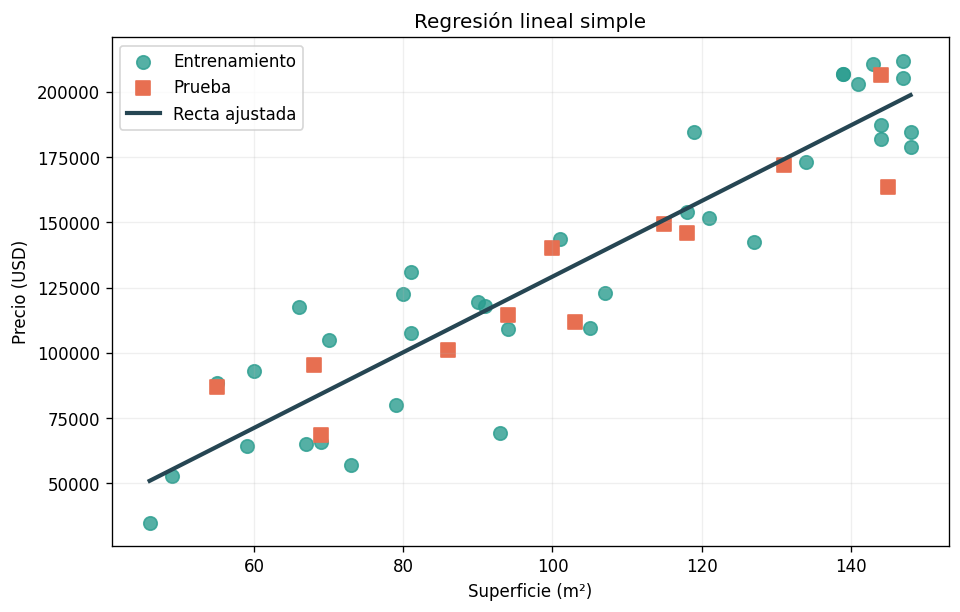

In [8]:
x_recta = pd.DataFrame({
    "superficie_m2": np.linspace(
        viviendas["superficie_m2"].min(),
        viviendas["superficie_m2"].max(),
        200,
    )
})
y_recta = modelo_simple.predict(x_recta)

plt.figure(figsize=(9, 5.5))
plt.scatter(
    X_train_s["superficie_m2"],
    y_train,
    color="#2A9D8F",
    label="Entrenamiento",
    alpha=0.8,
    s=65,
)
plt.scatter(
    X_test_s["superficie_m2"],
    y_test,
    color="#E76F51",
    label="Prueba",
    marker="s",
    s=70,
)
plt.plot(
    x_recta["superficie_m2"],
    y_recta,
    color="#264653",
    linewidth=2.5,
    label="Recta ajustada",
)
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (USD)")
plt.title("Regresión lineal simple")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


La recta pasa por el centro de la tendencia general, pero no atraviesa todos los puntos. El modelo resume la relación entre superficie y precio; no memoriza cada vivienda.

Las distancias verticales entre los puntos y la recta representan errores o residuos.


## 7. Realizar una predicción con la ecuación

Estimaremos el precio de una vivienda de 80 m² de dos maneras:

1. aplicando manualmente la ecuación;
2. usando `predict()`.


In [9]:
superficie_nueva = 80

prediccion_manual = (
    pendiente * superficie_nueva + intercepto
)
caso_80 = pd.DataFrame({
    "superficie_m2": [superficie_nueva]
})
prediccion_modelo = modelo_simple.predict(caso_80)[0]

pd.DataFrame({
    "procedimiento": [
        "Ecuación manual",
        "modelo.predict()",
    ],
    "precio_estimado_usd": [
        prediccion_manual,
        prediccion_modelo,
    ],
}).round(2)


,procedimiento,precio_estimado_usd
0,Ecuación manual,100250.78
1,modelo.predict(),100250.78


Ambos procedimientos producen el mismo resultado. `predict()` aplica internamente la ecuación formada por la pendiente y el intercepto aprendidos.

La predicción debe interpretarse como el valor esperado según la tendencia y la única variable disponible, no como el precio exacto de cualquier vivienda de 80 m².


## 8. Predicciones y residuos en datos no vistos

Calcularemos predicciones para el conjunto de prueba. Para cada caso:

```text
residuo = precio real - precio predicho
```

- residuo positivo: el modelo subestimó;
- residuo negativo: el modelo sobreestimó.


In [10]:
y_pred_simple = modelo_simple.predict(X_test_s)

resultados_simple = (
    X_test_s
    .assign(
        precio_real=y_test,
        precio_predicho=y_pred_simple,
        residuo=y_test - y_pred_simple,
    )
    .sort_values("precio_predicho")
)

resultados_simple.round(2)


,superficie_m2,precio_real,precio_predicho,residuo
22,55,87000.0,64025.25,22974.75
36,68,95500.0,82862.52,12637.48
35,69,68500.0,84311.55,-15811.55
33,86,101000.0,108944.91,-7944.91
14,94,114500.0,120537.08,-6037.08
26,100,140000.0,129231.21,10768.79
25,103,112000.0,133578.27,-21578.27
38,115,149500.0,150966.53,-1466.53
16,118,146000.0,155313.59,-9313.59
3,131,172000.0,174150.87,-2150.87


La tabla permite analizar cada error en dólares. Todavía no resumiremos todos los residuos mediante una métrica: antes conviene comprender qué significa cada diferencia y si los errores muestran una estructura.


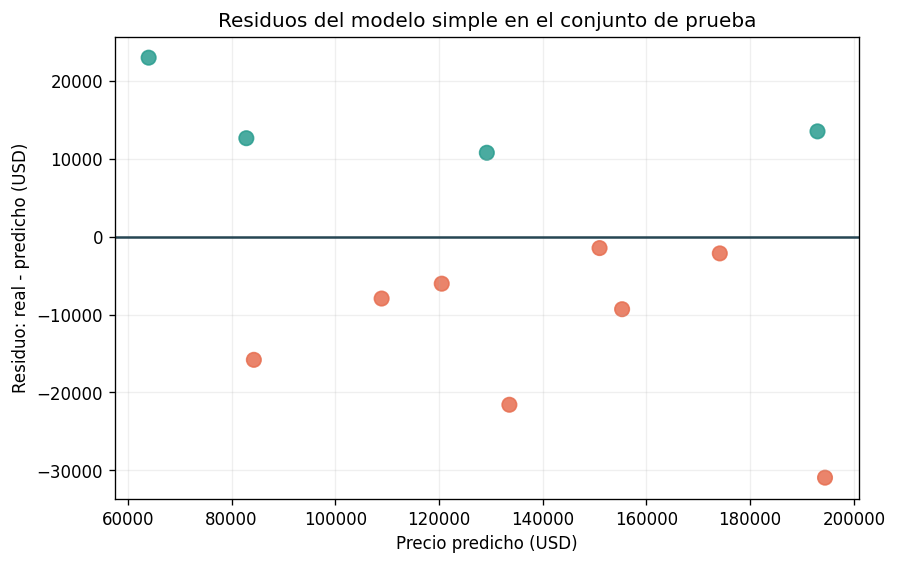

In [11]:
plt.figure(figsize=(8, 5))
plt.axhline(0, color="#264653", linewidth=1.5)
plt.scatter(
    resultados_simple["precio_predicho"],
    resultados_simple["residuo"],
    c=np.where(
        resultados_simple["residuo"] >= 0,
        "#2A9D8F",
        "#E76F51",
    ),
    s=75,
    alpha=0.85,
)
plt.xlabel("Precio predicho (USD)")
plt.ylabel("Residuo: real - predicho (USD)")
plt.title("Residuos del modelo simple en el conjunto de prueba")
plt.grid(alpha=0.2)
plt.show()


En un modelo lineal razonable, esperamos residuos distribuidos alrededor de cero sin una forma clara. Con pocos casos de prueba, el gráfico no permite establecer conclusiones definitivas, pero sí introduce una pregunta importante: **¿el modelo se equivoca al azar o sigue un patrón?**

Un patrón fuerte podría indicar que faltan variables relevantes o que una recta no representa bien la relación.


## 9. Pasar a una regresión lineal múltiple

El precio de una vivienda no depende únicamente de su superficie. Ahora incorporaremos cuatro variables numéricas:

- superficie;
- cantidad de ambientes;
- antigüedad;
- distancia al centro.

Usaremos los mismos índices de entrenamiento y prueba para que los casos reservados sean exactamente los mismos que en el modelo simple.


In [12]:
variables_multiples = [
    "superficie_m2",
    "ambientes",
    "antiguedad_anios",
    "distancia_centro_km",
]

X_multiple = viviendas[variables_multiples]
X_train_m = X_multiple.loc[X_train_s.index]
X_test_m = X_multiple.loc[X_test_s.index]

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train)

y_pred_multiple = modelo_multiple.predict(X_test_m)


El procedimiento es el mismo que en la regresión simple. La diferencia está en la cantidad de columnas de `X`.

Ahora la predicción se construye como una suma de aportes:

```text
predicción =
coeficiente_1 · superficie +
coeficiente_2 · ambientes +
coeficiente_3 · antigüedad +
coeficiente_4 · distancia +
intercepto
```


In [13]:
coeficientes = pd.Series(
    modelo_multiple.coef_,
    index=variables_multiples,
    name="coeficiente",
)

coeficientes.to_frame().round(2)


,coeficiente
superficie_m2,1125.61
ambientes,7412.63
antiguedad_anios,-483.33
distancia_centro_km,-3097.96


Cada coeficiente se interpreta manteniendo constantes las demás variables:

- un coeficiente positivo empuja la predicción hacia arriba;
- un coeficiente negativo la reduce;
- la magnitud depende de la unidad de medida.

Por ejemplo, el coeficiente de `antiguedad_anios` expresa el cambio estimado por un año adicional. El de `distancia_centro_km`, el cambio por un kilómetro adicional.

Estas relaciones son asociaciones aprendidas por el modelo. No prueban causalidad y pueden cambiar si incorporamos o quitamos variables.


## 10. Reconstruir una predicción múltiple

Tomaremos el primer caso del conjunto de prueba y calcularemos el aporte de cada variable. Después sumaremos el intercepto y compararemos el resultado con `predict()`.


In [14]:
indice_caso = X_test_m.index[0]
caso = X_test_m.loc[indice_caso]

aportes = caso * coeficientes
prediccion_reconstruida = (
    aportes.sum() + modelo_multiple.intercept_
)
prediccion_directa = modelo_multiple.predict(
    X_test_m.loc[[indice_caso]]
)[0]

tabla_aportes = pd.DataFrame({
    "valor_del_caso": caso,
    "coeficiente": coeficientes,
    "aporte_a_la_prediccion": aportes,
})

tabla_aportes.round(2)


,valor_del_caso,coeficiente,aporte_a_la_prediccion
superficie_m2,86.0,1125.61,96802.60
ambientes,3.0,7412.63,22237.88
antiguedad_anios,13.0,-483.33,-6283.30
distancia_centro_km,7.4,-3097.96,-22924.89


In [15]:
pd.DataFrame({
    "componente": [
        "Suma de aportes",
        "Intercepto",
        "Predicción reconstruida",
        "Predicción con predict()",
        "Precio real",
    ],
    "valor_usd": [
        aportes.sum(),
        modelo_multiple.intercept_,
        prediccion_reconstruida,
        prediccion_directa,
        y_test.loc[indice_caso],
    ],
}).round(2)


,componente,valor_usd
0,Suma de aportes,89832.30
1,Intercepto,26893.48
2,Predicción reconstruida,116725.78
3,Predicción con predict(),116725.78
4,Precio real,101000.00


La predicción reconstruida coincide con la obtenida mediante `predict()`. Esta transparencia es una de las ventajas centrales de la regresión lineal.

Sin embargo, cada aporte aislado no equivale al “valor real” de esa característica. Es una pieza matemática de la ecuación aprendida, cuyo significado depende del resto de las variables y del conjunto de datos.


## 11. Comparar resultados individuales

Agregaremos a la tabla de prueba las predicciones de ambos modelos. No calcularemos todavía una métrica global; observaremos si incorporar variables cambia las estimaciones de casos concretos.


In [16]:
comparacion = X_test_m.copy()
comparacion["precio_real"] = y_test
comparacion["pred_simple"] = y_pred_simple
comparacion["pred_multiple"] = y_pred_multiple
comparacion["error_simple"] = (
    comparacion["precio_real"] - comparacion["pred_simple"]
)
comparacion["error_multiple"] = (
    comparacion["precio_real"] - comparacion["pred_multiple"]
)

comparacion.round(2)


,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,precio_real,pred_simple,pred_multiple,error_simple,error_multiple
33,86,3,13,7.4,101000.0,108944.91,116725.78,-7944.91,-15725.78
14,94,3,6,10.3,114500.0,120537.08,120129.91,-6037.08,-5629.91
26,100,3,7,7.9,140000.0,129231.21,133835.35,10768.79,6164.65
3,131,6,49,3.8,172000.0,174150.87,183368.94,-2150.87,-11368.94
36,68,4,23,1.3,95500.0,82862.52,117941.64,12637.48,-22441.64
38,115,5,3,13.1,149500.0,150966.53,151368.72,-1466.53,-1868.72
39,145,5,35,10.4,163500.0,194437.16,178034.98,-30937.16,-14534.98
16,118,6,24,14.1,146000.0,155313.59,148910.29,-9313.59,-2910.29
25,103,3,41,8.8,112000.0,133578.27,117990.79,-21578.27,-5990.79
22,55,2,2,13.1,87000.0,64025.25,62077.47,22974.75,24922.53


Agregar variables modifica las predicciones, pero **más variables no garantiza automáticamente un mejor modelo**. Para decidirlo de manera rigurosa necesitaremos resumir los errores sobre datos no vistos mediante métricas adecuadas, tema del próximo capítulo.

También debemos recordar que este modelo numérico no utiliza `barrio`. Una variable categórica podría incorporarse mediante One-Hot Encoding y un `Pipeline`, como vimos al estudiar preprocesamiento.


## 12. Los coeficientes dependen de las unidades

Entrenaremos dos modelos equivalentes:

- uno mide la superficie en metros cuadrados;
- otro la expresa en decenas de metros cuadrados.

La información es la misma. Solo cambia la unidad.


In [17]:
X_metros = X_train_s.copy()
X_decenas = X_train_s.rename(
    columns={"superficie_m2": "superficie_decenas_m2"}
) / 10

modelo_metros = LinearRegression().fit(X_metros, y_train)
modelo_decenas = LinearRegression().fit(X_decenas, y_train)

pd.DataFrame({
    "unidad": [
        "Por 1 m²",
        "Por 10 m²",
    ],
    "coeficiente": [
        modelo_metros.coef_[0],
        modelo_decenas.coef_[0],
    ],
    "prediccion_para_80_m2": [
        modelo_metros.predict(
            pd.DataFrame({"superficie_m2": [80]})
        )[0],
        modelo_decenas.predict(
            pd.DataFrame({"superficie_decenas_m2": [8]})
        )[0],
    ],
}).round(2)


,unidad,coeficiente,prediccion_para_80_m2
0,Por 1 m²,1449.02,100250.78
1,Por 10 m²,14490.21,100250.78


El coeficiente expresado por 10 m² es diez veces mayor que el coeficiente por 1 m², pero la predicción para la misma vivienda no cambia.

Por eso, un coeficiente numéricamente grande no demuestra que una variable sea más importante. Primero debemos considerar la escala y la unidad en que está medida.


## 13. Sensibilidad a un valor extremo

La regresión lineal puede verse afectada por casos alejados del patrón general. Agregaremos una vivienda ficticia con un precio extremadamente alto y compararemos la recta original con la nueva.

El objetivo no es decidir que todo valor extremo debe eliminarse. En un proyecto real habría que investigar si el caso es válido, si contiene un error o si pertenece a otro segmento.


In [18]:
X_con_extremo = pd.concat([
    X_train_s,
    pd.DataFrame(
        {"superficie_m2": [145]},
        index=["caso_extremo"],
    ),
])
y_con_extremo = pd.concat([
    y_train,
    pd.Series(
        [420000],
        index=["caso_extremo"],
        name="precio_usd",
    ),
])

modelo_con_extremo = LinearRegression()
modelo_con_extremo.fit(X_con_extremo, y_con_extremo)

pd.DataFrame({
    "modelo": [
        "Sin caso extremo",
        "Con caso extremo",
    ],
    "pendiente": [
        modelo_simple.coef_[0],
        modelo_con_extremo.coef_[0],
    ],
    "intercepto": [
        modelo_simple.intercept_,
        modelo_con_extremo.intercept_,
    ],
}).round(2)


,modelo,pendiente,intercepto
0,Sin caso extremo,1449.02,-15670.92
1,Con caso extremo,1675.01,-32906.02


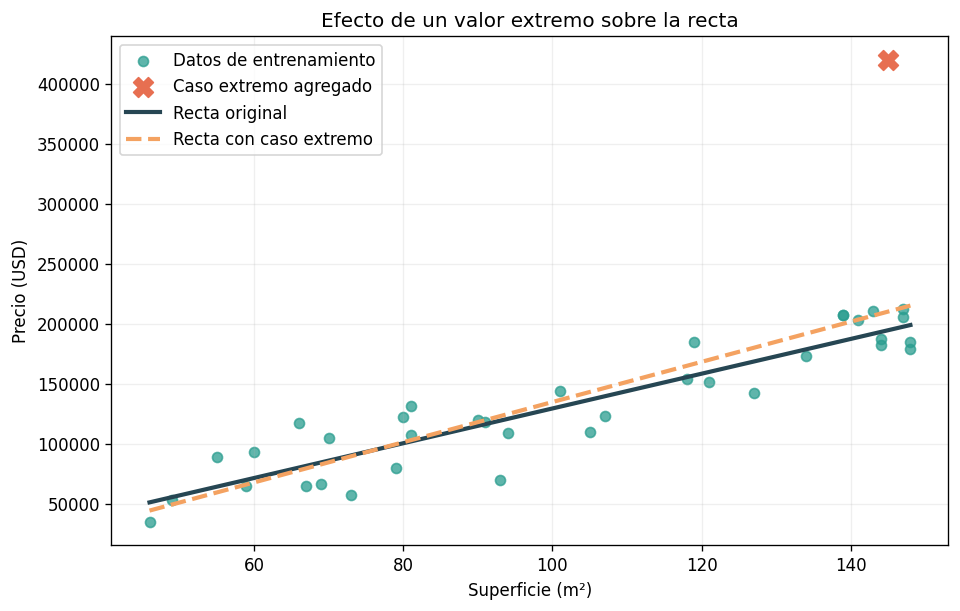

In [19]:
y_recta_extremo = modelo_con_extremo.predict(x_recta)

plt.figure(figsize=(9, 5.5))
plt.scatter(
    X_train_s["superficie_m2"],
    y_train,
    color="#2A9D8F",
    alpha=0.75,
    label="Datos de entrenamiento",
)
plt.scatter(
    [145],
    [420000],
    color="#E76F51",
    marker="X",
    s=140,
    label="Caso extremo agregado",
)
plt.plot(
    x_recta["superficie_m2"],
    y_recta,
    color="#264653",
    linewidth=2.5,
    label="Recta original",
)
plt.plot(
    x_recta["superficie_m2"],
    y_recta_extremo,
    color="#F4A261",
    linewidth=2.5,
    linestyle="--",
    label="Recta con caso extremo",
)
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (USD)")
plt.title("Efecto de un valor extremo sobre la recta")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


Un único punto muy alejado modifica la pendiente y el intercepto. La recta intenta reducir los errores del conjunto completo, por lo que el caso extremo puede inclinarla y afectar las predicciones de muchas otras viviendas.

La respuesta correcta no es eliminarlo automáticamente, sino comprenderlo antes de decidir.


## 14. Cuando una recta no alcanza

Crearemos ahora un fenómeno cuya relación es claramente curva. Ajustaremos una recta para comprobar que `LinearRegression` siempre produce una relación lineal, aun cuando los datos tengan otra forma.


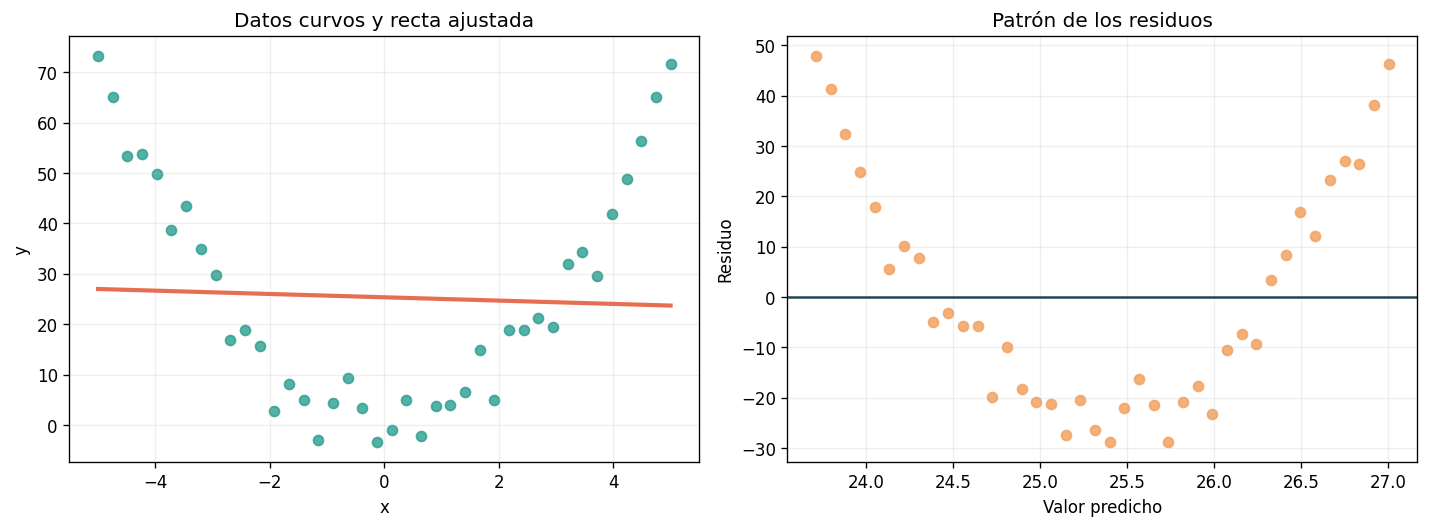

In [20]:
x_curva = np.linspace(-5, 5, 40)
y_curva = 3 * x_curva**2 + rng.normal(0, 4, size=len(x_curva))

X_curva = pd.DataFrame({"x": x_curva})
modelo_curva = LinearRegression().fit(X_curva, y_curva)
y_curva_pred = modelo_curva.predict(X_curva)
residuos_curva = y_curva - y_curva_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(
    x_curva,
    y_curva,
    color="#2A9D8F",
    alpha=0.8,
)
axes[0].plot(
    x_curva,
    y_curva_pred,
    color="#E76F51",
    linewidth=2.5,
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Datos curvos y recta ajustada")
axes[0].grid(alpha=0.2)

axes[1].axhline(0, color="#264653", linewidth=1.5)
axes[1].scatter(
    y_curva_pred,
    residuos_curva,
    color="#F4A261",
    alpha=0.85,
)
axes[1].set_xlabel("Valor predicho")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Patrón de los residuos")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


La recta no puede seguir la forma curva. Los residuos tampoco quedan distribuidos sin estructura: aparecen errores sistemáticos relacionados con la zona del gráfico.

Este patrón es una señal de que la forma del modelo no representa adecuadamente el fenómeno. Una regresión lineal puede seguir siendo una referencia útil, pero sería razonable explorar transformaciones o modelos más flexibles.


## 15. Extrapolar más allá de los datos

La recta puede calcular una predicción para cualquier superficie, incluso lejos del rango observado. Compararemos un caso dentro del rango habitual con otro muy alejado.


In [21]:
superficies_consulta = pd.DataFrame({
    "superficie_m2": [80, 500]
})
predicciones_consulta = modelo_simple.predict(
    superficies_consulta
)

pd.DataFrame({
    "superficie_m2": superficies_consulta["superficie_m2"],
    "precio_estimado_usd": predicciones_consulta,
    "situacion": [
        "Dentro del rango observado",
        "Muy lejos del rango observado",
    ],
}).round(2)


,superficie_m2,precio_estimado_usd,situacion
0,80,100250.78,Dentro del rango observado
1,500,708839.72,Muy lejos del rango observado


El modelo puede producir ambos números, pero no ofrece la misma evidencia para interpretarlos. La estimación de 80 m² está dentro del rango conocido; la de 500 m² prolonga la recta hacia una región sin casos de entrenamiento.

La posibilidad matemática de extrapolar no garantiza que la relación real continúe de la misma manera.


## 16. Actividad breve

Modificá el valor de `superficie_actividad` y ejecutá la celda. El código mostrará la predicción del modelo simple e indicará si el valor se encuentra dentro del rango de superficies usado para entrenarlo.


In [22]:
superficie_actividad = 100

caso_actividad = pd.DataFrame({
    "superficie_m2": [superficie_actividad]
})
prediccion_actividad = modelo_simple.predict(
    caso_actividad
)[0]

min_entrenamiento = X_train_s["superficie_m2"].min()
max_entrenamiento = X_train_s["superficie_m2"].max()
dentro_del_rango = (
    min_entrenamiento
    <= superficie_actividad
    <= max_entrenamiento
)

print(f"Superficie: {superficie_actividad} m²")
print(f"Precio estimado: USD {prediccion_actividad:,.2f}")
print(
    "¿Dentro del rango de entrenamiento?: "
    f"{'Sí' if dentro_del_rango else 'No'}"
)


Superficie: 100 m²
Precio estimado: USD 129,231.21
¿Dentro del rango de entrenamiento?: Sí


Probá, por ejemplo, con `60`, `120`, `20` y `400`.

Luego respondé:

1. ¿La predicción aumenta siempre en la misma cantidad por cada metro cuadrado adicional?
2. ¿Qué propiedad de una ecuación lineal explica ese comportamiento?
3. ¿Interpretarías con la misma confianza una predicción para 100 m² y otra para 400 m²?
4. ¿Qué variables importantes ignora el modelo simple?


## 17. Síntesis

En este cuaderno:

- entrenamos una regresión lineal simple;
- obtuvimos la pendiente y el intercepto;
- reconstruimos una predicción mediante la ecuación;
- observamos la recta y los residuos;
- entrenamos una regresión lineal múltiple;
- analizamos el aporte de cada variable;
- comprobamos que los coeficientes dependen de las unidades;
- observamos la influencia de un valor extremo;
- identificamos un patrón curvo que una recta no puede capturar;
- diferenciamos interpolación y extrapolación.

La regresión lineal es simple, rápida e interpretable. Esa claridad la convierte en un excelente punto de partida, pero no evita la necesidad de revisar los datos, las relaciones entre variables y los errores.


## Para pensar

1. Si dos variables predictoras están muy relacionadas, ¿por qué puede ser difícil interpretar sus coeficientes por separado?
2. ¿Por qué el intercepto puede ser matemáticamente necesario y, al mismo tiempo, carecer de una interpretación práctica?
3. ¿Un coeficiente positivo demuestra que la variable causa un aumento en el objetivo?
4. ¿Qué patrón esperarías observar en los residuos de un modelo lineal razonable?
5. ¿Por qué un valor extremo no debería eliminarse de forma automática?
6. ¿Qué información necesitaremos para comparar de manera rigurosa el modelo simple y el múltiple?
